In [2]:
# Importing Packages
from qiskit.circuit import Parameter
from qiskit.quantum_info import Operator
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import UnitaryGate
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile, qpy
import itertools
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector

ImportError: Qiskit is installed in an invalid environment that has both Qiskit >=1.0 and an earlier version. You should create a new virtual environment, and ensure that you do not mix dependencies between Qiskit <1.0 and >=1.0. Any packages that depend on 'qiskit-terra' are not compatible with Qiskit 1.0 and will need to be updated. Qiskit unfortunately cannot enforce this requirement during environment resolution. See https://qisk.it/packaging-1-0 for more detail.

In [2]:
nx = 2  # number of input features -- this is what you vary based on the number of features 
nw = 2 * nx     # number of weights

In [3]:
# Defining Parameters
x     = ParameterVector('x', nx)
omega = ParameterVector('w', 2*nx)

# ===========================
# Making the parameterized U
U = QuantumCircuit(nx, name='U')

# Iterate over all computational basis states of length nx
for basis_state in itertools.product(['0','1'], repeat=nx):
    basis_state = ''.join(basis_state)

    # --- Flip into this basis state
    for i, bit in enumerate(basis_state):
        if bit == '0':
            U.x(i)

    # --- Build the phase expression
    phase_expr = 0
    for i, bit in enumerate(basis_state):
        idx = 2*i + int(bit)   # ω_{2i} if qubit=0, ω_{2i+1} if qubit=1
        phase_expr += x[i] * omega[idx]

    # --- Apply controlled phase (control=0, target=last qubit)
    U.cp(phase_expr, 0, nx-1)

    # --- Undo flips
    for i, bit in enumerate(basis_state):
        if bit == '0':
            U.x(i)

# ===========================
# Transpile circuit
U = transpile(U)

# ===========================
# Convert to gate form
U_gate = U.to_gate()
CU_gate = U.control(1)

In [4]:
# Drawing the U Gate
U.draw()

┌───┐                                                           ┌───┐»
q_0: ┤ X ├─■───────────────────────────────■─────────────────────────┤ X ├»
     ├───┤ │P(w[0]*x[0] + w[2]*x[1]) ┌───┐ │P(w[0]*x[0] + w[3]*x[1]) ├───┤»
q_1: ┤ X ├─■─────────────────────────┤ X ├─■─────────────────────────┤ X ├»
     └───┘                           └───┘                           └───┘»
«                                                                
«q_0: ─■───────────────────────────────■─────────────────────────
«      │P(w[1]*x[0] + w[2]*x[1]) ┌───┐ │P(w[1]*x[0] + w[3]*x[1]) 
«q_1: ─■─────────────────────────┤ X ├─■─────────────────────────
«                                └───┘

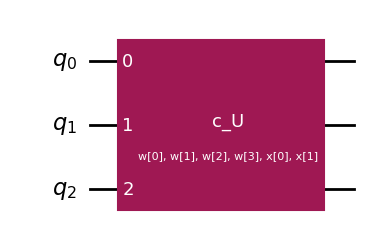

In [5]:
qc = QuantumCircuit(CU_gate.num_qubits)
qc.append(CU_gate, range(CU_gate.num_qubits))

qc.draw("mpl")


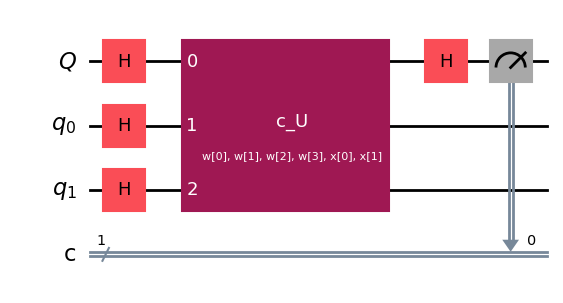

In [6]:
# Construct the full QNN circuit
num_classifier_qubits    = 1
num_computational_qubits = nx
num_qubits = num_classifier_qubits + num_computational_qubits

q_class = QuantumRegister(num_classifier_qubits,    name='Q')
q_comp  = QuantumRegister(num_computational_qubits, name='q')
c       = ClassicalRegister(1, name='c')

qc = QuantumCircuit(q_class, q_comp, c, name='qc')

# Step 1: Initialize classifier qubit in |+>
qc.h(q_class[0])

# Step 2: Put computational qubits in uniform superposition
for i in range(nx):
    qc.h(q_comp[i])

# Step 3: Apply controlled-U
qc.append(CU_gate, [q_class[0]] + q_comp[:])

# Step 4: Hadamard on classifier qubit (activation)
qc.h(q_class[0])

# Step 5: Measure classifier qubit
qc.measure(q_class[0], c[0])

# ===============================================
# Draw circuit
qc.draw("mpl")

In [7]:
# Exporting the Parameterized Quantum Circuit 'qc' as a .qpy file

with open(f"parameterized_qc_{nx}.qpy", "wb") as qpy_file_write:
    qpy.dump(qc, qpy_file_write)